<a href="https://colab.research.google.com/github/NostagitEgg/abarca_colab_ccs8/blob/main/Copy_of_CC19_Data_Mining_Project_(JOB).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Group Name: The Unempl*yed

Group Members:

Abarca, James Gabriel

Aliba, Hezron Art

Beligan, Van Casey

Bona, Jethro Jo

Changes from Phase 1:  
* Problem Definition: To help Recruitment Agencies in catering the best job positions in an AI or Database field for college graduates and unemployed individuals.
* Target Variable: Salary given by the Job Position
# Phase 2: Data Preprocessing and Exploration

Submission: Submit a cleaned dataset with a report on preprocessing and exploration steps.

In [35]:
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

# Replace the URL below with the raw link you copied
url = "https://raw.githubusercontent.com/NostagitEgg/abarca_colab_ccs8/main/ai_jobs.csv"
ai_jobs_df = pd.read_csv(url)

# Display the first few rows of the DataFrame
print(ai_jobs_df.head())

         job_id                  job_title  company_type    industry  \
0  0IFD0TVBDIVU             MLOps Engineer  Research Lab   Education   
1  ZMF8MDD4V30T               Data Analyst       Startup   Education   
2  CX1945NQ4FMY             MLOps Engineer  Research Lab        Tech   
3  QJ7YHL1C32OC          Applied Scientist  Research Lab  Healthcare   
4  F0T0PVN9ER14  Machine Learning Engineer  Research Lab     Finance   

     country    city remote_type experience_level  min_experience_years  \
0  Australia  Remote      Remote            Entry                     0   
1    Germany  Remote      Remote            Entry                     0   
2     Canada  Remote      Remote           Senior                     5   
3  Australia  Remote      Remote            Entry                     0   
4  Australia  Sydney      Hybrid              Mid                     2   

   salary_min_usd  salary_max_usd employment_type  posted_year company_size  
0           56873           72223     

# Step 1: Data Cleaning
* Identify columns with missing values.
* Decide how to handle these missing values:
  * For numerical columns, fill missing values with the mean, median, or other suitable values.
  * For categorical columns, replace missing values with the mode (most frequent category).
* If the missing data is too significant (e.g., more than 40-50%), consider removing the column.
* For rows with missing target values, remove the entire row.


In [36]:
#Step 1.1 Handle Missing Values

#Checking for missing values
missing_values = ai_jobs_df.isnull().sum()
missing_values = missing_values[missing_values > 0]
if not missing_values.empty:
    print("Columns with missing values and their counts:")
    display(missing_values)
else:
    print("No missing values found in the dataset.")

#Dropping any unimportant features

# Dropping city
ai_jobs_df.drop(columns=['city'], inplace=True)
# Dropping employment_type
print(ai_jobs_df['employment_type'].value_counts())
ai_jobs_df.drop(columns=['employment_type'], inplace=True)

display(ai_jobs_df.head())

No missing values found in the dataset.
employment_type
Full-time    50000
Name: count, dtype: int64


,job_id,job_title,company_type,industry,country,remote_type,experience_level,min_experience_years,salary_min_usd,salary_max_usd,posted_year,company_size
0,0IFD0TVBDIVU,MLOps Engineer,Research Lab,Education,Australia,Remote,Entry,0,56873,72223,2023,Large
1,ZMF8MDD4V30T,Data Analyst,Startup,Education,Germany,Remote,Entry,0,54803,85599,2024,Medium
2,CX1945NQ4FMY,MLOps Engineer,Research Lab,Tech,Canada,Remote,Senior,5,149980,175806,2021,Large
3,QJ7YHL1C32OC,Applied Scientist,Research Lab,Healthcare,Australia,Remote,Entry,0,53483,86477,2023,Medium
4,F0T0PVN9ER14,Machine Learning Engineer,Research Lab,Finance,Australia,Hybrid,Mid,2,102977,127298,2023,Large


We first checked if there are any missing values in the dataset with this code. Fortunately, there are none.

However, we chose to drop some columns as they may be unnecessary for the goal of this data mining. Some are also redundant.
Features dropped:
- **city**: Since the data includes if the job is remote, which is redunant due to remote type.
- **employment_type**: It seems that almost all the jobs are already full-time, which makes the column unnecessary. It can only be useful if there are also part-time jobs to compare the salaries with.

In [37]:
#Step 1.2 Handle Outliers

import numpy as np
#Calculate Z-scores for salary_min_usd
ai_jobs_df['salary_min_usd_zscore'] = np.abs((ai_jobs_df['salary_min_usd'] - ai_jobs_df['salary_min_usd'].mean()) / ai_jobs_df['salary_min_usd'].std())

#Z-scores for salary_max_usd
ai_jobs_df['salary_max_usd_zscore'] = np.abs((ai_jobs_df['salary_max_usd'] - ai_jobs_df['salary_max_usd'].mean()) / ai_jobs_df['salary_max_usd'].std())

#Define a Z-score threshold
z_score_threshold = 3

#Identify outliers for salary_min_usd
outliers_min_salary = ai_jobs_df[ai_jobs_df['salary_min_usd_zscore'] > z_score_threshold]

#Outliers for salary_max_usd
outliers_max_salary = ai_jobs_df[ai_jobs_df['salary_max_usd_zscore'] > z_score_threshold]
print(f"Outliers in 'salary_min_usd' (Z-score > {z_score_threshold}):")
display(outliers_min_salary[['job_id', 'job_title', 'salary_min_usd', 'salary_min_usd_zscore']])
print(f"\nOutliers in 'salary_max_usd' (Z-score > {z_score_threshold}):")
display(outliers_max_salary[['job_id', 'job_title', 'salary_max_usd', 'salary_max_usd_zscore']])

Outliers in 'salary_min_usd' (Z-score > 3):


,job_id,job_title,salary_min_usd,salary_min_usd_zscore



Outliers in 'salary_max_usd' (Z-score > 3):


,job_id,job_title,salary_max_usd,salary_max_usd_zscore


After confirming that there are no missing values in the dataset, we then check if there are any outliers by converting the data in the columns that have the highest variance in values, namely, salary_min_usd and salary_max_usd, into z-scores and checking for any that have a z-score higher than 3.

As shown in the code snippet above, there are no outliers that is showing up in the tables.

# Step 2: Data Transformation

In [38]:
#Step 2.1 Normalize Numerical Features

numerical_features = [
    'salary_min_usd',
    'salary_max_usd'
]

scaler = MinMaxScaler()
ai_jobs_df[numerical_features] = scaler.fit_transform(ai_jobs_df[numerical_features])

# display(ai_jobs_df.head())
print("-------------------Normalized Numerical Features-------------------")
print(ai_jobs_df[numerical_features], )

print("\n--------------Z-scores of salary_min_usd, and salary_max_usd------------------")
print(ai_jobs_df[['salary_min_usd_zscore', 'salary_max_usd_zscore']])

-------------------Normalized Numerical Features-------------------
       salary_min_usd  salary_max_usd
0            0.065458        0.062809
1            0.045743        0.179122
2            0.952200        0.963530
3            0.033172        0.186757
4            0.504548        0.541722
...               ...             ...
49995        0.893342        0.953896
49996        0.859513        0.843417
49997        0.009076        0.192678
49998        0.130592        0.097504
49999        0.938104        0.886713

[50000 rows x 2 columns]

--------------Z-scores of salary_min_usd, and salary_max_usd------------------
       salary_min_usd_zscore  salary_max_usd_zscore
0                   1.187752               1.295858
1                   1.243633               0.939463
2                   1.325702               1.464045
3                   1.279266               0.916069
4                   0.056840               0.171580
...                      ...                    ...
49995 

Here in the code snippet above, the following numerical features salary_min_usd and salary_max_usd is normalized using Min-Max Scaling and z-score standardization.

In [39]:
#Step 2.2 Encode Categorical Features

#Label encoding application
remote_type_mapping = {
    'Remote': 0,
    'Hybrid': 1,
    'Onsite': 2
}
experience_level_mapping = {
    'Entry': 0,
    'Mid': 1,
    'Senior': 2
}
company_size_mapping = {
    'Small': 0,
    'Medium': 1,
    'Large': 2
}
#Apply to the respective columns
ai_jobs_df['remote_type'] = ai_jobs_df['remote_type'].map(remote_type_mapping)
ai_jobs_df['experience_level'] = ai_jobs_df['experience_level'].map(experience_level_mapping)
ai_jobs_df['company_size'] = ai_jobs_df['company_size'].map(company_size_mapping)

print("----------Dataset after label encoding (remote_type, experience_level, company_size):----------")
print(ai_jobs_df[['remote_type', 'experience_level', 'company_size']])
#display(ai_jobs_df.head())

----------Dataset after label encoding (remote_type, experience_level, company_size):----------
       remote_type  experience_level  company_size
0                0                 0             2
1                0                 0             1
2                0                 2             2
3                0                 0             1
4                1                 1             2
...            ...               ...           ...
49995            2                 2             1
49996            2                 2             1
49997            2                 0             0
49998            1                 0             2
49999            1                 2             0

[50000 rows x 3 columns]


We used label encoding for the columns remote_type, experience_level, and company_size, converting ordinal data into numerical data.

In [40]:
#Step 2.3 Feature Engineering
#Target Variable: salary_min_max, salary_max

#Adding the Average between min and max salary, also inserting next to these data
ai_jobs_df['average_salary'] = ai_jobs_df[['salary_min_usd', 'salary_max_usd']].mean(axis=1)

#Binning the average_salary into salary groups
bins = [0, 0.2, 0.4, 0.6, 0.8, 1]
labels = ['0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8+']

ai_jobs_df['avg_salary_groups'] = pd.cut(ai_jobs_df['average_salary'], bins=bins, labels=labels, right=False)

print(ai_jobs_df[['salary_min_usd', 'salary_max_usd', 'average_salary', 'avg_salary_groups']])

# Drop salary_min_usd, salary_max_usd, and their z-score columns as they are no longer needed
ai_jobs_df.drop(columns=['salary_min_usd', 'salary_max_usd', 'salary_min_usd_zscore', 'salary_max_usd_zscore'], inplace=True)
print("\nDataFrame after dropping 'salary_min_usd', 'salary_max_usd', and z-score columns:")
display(ai_jobs_df.head())

       salary_min_usd  salary_max_usd  average_salary avg_salary_groups
0            0.065458        0.062809        0.064133             0-0.2
1            0.045743        0.179122        0.112433             0-0.2
2            0.952200        0.963530        0.957865              0.8+
3            0.033172        0.186757        0.109964             0-0.2
4            0.504548        0.541722        0.523135           0.4-0.6
...               ...             ...             ...               ...
49995        0.893342        0.953896        0.923619              0.8+
49996        0.859513        0.843417        0.851465              0.8+
49997        0.009076        0.192678        0.100877             0-0.2
49998        0.130592        0.097504        0.114048             0-0.2
49999        0.938104        0.886713        0.912409              0.8+

[50000 rows x 4 columns]

DataFrame after dropping 'salary_min_usd', 'salary_max_usd', and z-score columns:


,job_id,job_title,company_type,industry,country,remote_type,experience_level,min_experience_years,posted_year,company_size,average_salary,avg_salary_groups
0,0IFD0TVBDIVU,MLOps Engineer,Research Lab,Education,Australia,0,0,0,2023,2,0.064133,0-0.2
1,ZMF8MDD4V30T,Data Analyst,Startup,Education,Germany,0,0,0,2024,1,0.112433,0-0.2
2,CX1945NQ4FMY,MLOps Engineer,Research Lab,Tech,Canada,0,2,5,2021,2,0.957865,0.8+
3,QJ7YHL1C32OC,Applied Scientist,Research Lab,Healthcare,Australia,0,0,0,2023,1,0.109964,0-0.2
4,F0T0PVN9ER14,Machine Learning Engineer,Research Lab,Finance,Australia,1,1,2,2023,2,0.523135,0.4-0.6


New Features added:
- **average_salary**: The average of salary_min_usd and salary_max_usd to be used as the target variable.
- **avg_salary_groups**: Binning the average salary to groups to be able to help making decisions on whether a job position's salary is "below expectations" or "favorable".

After this, since average_salary is the new target variable, salary_min_usd and salary_max_usd, and both columns containing their z-scores are dropped. This reduces complexity, and would help in Step 3.

# Step 3: Data Reduction Methods

In [41]:
#Step 3.1 Dimensionality Reduction

#Select only numerical columns from the dataset
numerical_data = ai_jobs_df.select_dtypes(include=[np.number])

#Standardize the numerical data
scaler = StandardScaler()
numerical_scaled = scaler.fit_transform(numerical_data)

#Apply Principal Component Analysis (PCA)
pca = PCA(n_components=0.95) #retains 95% of the variances

#Fit PCA to the standardized data and transform it
pca_result = pca.fit_transform(numerical_scaled)

#Compare number of features before and after PCA
print(f"Original shape: {numerical_data.shape}")
print(f"Shape after PCA: {pca_result.shape}")

display(ai_jobs_df.head())

Original shape: (50000, 6)
Shape after PCA: (50000, 4)


,job_id,job_title,company_type,industry,country,remote_type,experience_level,min_experience_years,posted_year,company_size,average_salary,avg_salary_groups
0,0IFD0TVBDIVU,MLOps Engineer,Research Lab,Education,Australia,0,0,0,2023,2,0.064133,0-0.2
1,ZMF8MDD4V30T,Data Analyst,Startup,Education,Germany,0,0,0,2024,1,0.112433,0-0.2
2,CX1945NQ4FMY,MLOps Engineer,Research Lab,Tech,Canada,0,2,5,2021,2,0.957865,0.8+
3,QJ7YHL1C32OC,Applied Scientist,Research Lab,Healthcare,Australia,0,0,0,2023,1,0.109964,0-0.2
4,F0T0PVN9ER14,Machine Learning Engineer,Research Lab,Finance,Australia,1,1,2,2023,2,0.523135,0.4-0.6


In the cell above, the PCA was used to reduce the "dimensions" caused by the large number of features.

In [42]:
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import LabelEncoder # Keep import as it might be used elsewhere in a chain

# Select only numerical columns from the dataset
numerical_data = ai_jobs_df.select_dtypes(include=[np.number])

# Standardize the numerical data (though not strictly necessary for f_regression's score calculation, good practice)
scaler = StandardScaler()
numerical_scaled = scaler.fit_transform(numerical_data)

X = ai_jobs_df[['remote_type', 'experience_level', 'min_experience_years', 'posted_year', 'company_size']]

# Change target to the continuous 'average_salary' for f_regression
y = ai_jobs_df['average_salary']

# Applying ANOVA F-test for regression
anova_selector = SelectKBest(score_func=f_regression, k='all') # Use 'all' to get scores for all features
anova_selector.fit(X, y)

# Printing selected feature scores and feature names
print("Feature Scores:")
for feature, score in zip(X.columns, anova_selector.scores_):
    print(f"{feature}: {score:.4f}")

# You can also get p-values if needed
# print("P-values:")
# for feature, p_value in zip(X.columns, anova_selector.pvalues_):
#     print(f"{feature}: {p_value:.4f}")

# To see the selected features (e.g., if k was specified)
# selected_features_df = X.iloc[:, anova_selector.get_support(indices=True)]
# print("\nSelected Features (if k was specified):")
# display(selected_features_df.head())

Feature Scores:
remote_type: 0.9740
experience_level: 3009959.9221
min_experience_years: 3302268.0447
posted_year: 0.9832
company_size: 0.0035


Using ANOVA (Analysis of Variance) F-test, it could score each numerical feature based on their variances if they are truly relevant or needed in affecting the target variable, which is the average_salary as the target variable.
This step however, of the group would be honest, is the hardest to understand and implement.

# Full Colab Implementation

Group Name: The Unempl*yed

Group Members:

Abarca, James Gabriel

Aliba, Hezron Art

Beligan, Van Casey

Bona, Jethro Jo

# PHASE 3: Model Selection, Training, and Evaluation

##Step 1, 2 and 3: Model Selection, Training and Evaluation
Target Variable: avg_salary_groups (Grouping of Average Salary) -> Categorical Variable

Therefore, the task is classification.

We decided to test 3 different models for our project before selecting a final one:

- Decision Trees, which is a simple model to act as a baseline.
- Support Vector Machines (SVM), which is if Decision Trees underperform, as Decision Trees are mostly used for small, structured data.
- Naive Bayes Algorithm for more exploration.


DECISION TREES

In [44]:
#Decision Trees Model
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
#Reload the original dataset to ensure a clean state for reprocessing
ai_jobs_df = pd.read_csv(url)
# --- Reapply preprocessing steps ---
#Step 1.1 Handle Missing Values & Drop unimportant features
ai_jobs_df.drop(columns=['city', 'employment_type'], inplace=True)
#Step 1.2 Handle Outliers - adds z-score columns for potential dropping
import numpy as np
ai_jobs_df['salary_min_usd_zscore'] = np.abs((ai_jobs_df['salary_min_usd'] - ai_jobs_df['salary_min_usd'].mean()) / ai_jobs_df['salary_min_usd'].std())
ai_jobs_df['salary_max_usd_zscore'] = np.abs((ai_jobs_df['salary_max_usd'] - ai_jobs_df['salary_max_usd'].mean()) / ai_jobs_df['salary_max_usd'].std())

#Step 2.1 Normalize Numerical Features
numerical_features = [
    'salary_min_usd',
    'salary_max_usd'
]
scaler = MinMaxScaler()
ai_jobs_df[numerical_features] = scaler.fit_transform(ai_jobs_df[numerical_features])

# Step 2.2 Encode Categorical Features
remote_type_mapping = {
    'Remote': 0,
    'Hybrid': 1,
    'Onsite': 2
}
experience_level_mapping = {
    'Entry': 0,
    'Mid': 1,
    'Senior': 2
}
company_size_mapping = {
    'Small': 0,
    'Medium': 1,
    'Large': 2
}
ai_jobs_df['remote_type'] = ai_jobs_df['remote_type'].map(remote_type_mapping)
ai_jobs_df['experience_level'] = ai_jobs_df['experience_level'].map(experience_level_mapping)
ai_jobs_df['company_size'] = ai_jobs_df['company_size'].map(company_size_mapping)

#Step 2.3 Feature Engineering
ai_jobs_df['average_salary'] = ai_jobs_df[['salary_min_usd', 'salary_max_usd']].mean(axis=1)

bins = [0, 0.2, 0.4, 0.6, 0.8, 1]
labels = ['0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8+']
ai_jobs_df['avg_salary_groups'] = pd.cut(ai_jobs_df['average_salary'], bins=bins, labels=labels, right=False)

#Drop salary_min_usd, salary_max_usd, and their z-score columns as they are no longer needed
ai_jobs_df.drop(columns=['salary_min_usd', 'salary_max_usd', 'salary_min_usd_zscore', 'salary_max_usd_zscore'], inplace=True)

# --- End of re-application of previous steps ---

#Drop the 'job_id' column
ai_jobs_df.drop(columns=['job_id'], inplace=True)

#Create a list of categorical features to be one-hot encoded
categorical_features_ohe = ['job_title', 'company_type', 'industry', 'country']

#Apply one-hot encoding to these categorical features
ai_jobs_df = pd.get_dummies(ai_jobs_df, columns=categorical_features_ohe, drop_first=True)

#Map the 'avg_salary_groups' column to numerical labels
salary_group_mapping = {
    '0-0.2': 0,
    '0.2-0.4': 1,
    '0.4-0.6': 2,
    '0.6-0.8': 3,
    '0.8+': 4
}
ai_jobs_df['avg_salary_groups_encoded'] = ai_jobs_df['avg_salary_groups'].map(salary_group_mapping)

#Define features X and target variable y - FIX: Exclude 'average_salary' to prevent data leakage
X = ai_jobs_df.drop(columns=['avg_salary_groups', 'avg_salary_groups_encoded', 'average_salary'])
y = ai_jobs_df['avg_salary_groups_encoded']

#Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)
print("\nFirst 5 rows of X_train:")
display(X_train.head())
print("\nFirst 5 values of y_train:")
display(y_train.head())

Shape of X_train: (40000, 21)
Shape of X_test: (10000, 21)
Shape of y_train: (40000,)
Shape of y_test: (10000,)

First 5 rows of X_train:


,remote_type,experience_level,min_experience_years,posted_year,company_size,job_title_Applied Scientist,job_title_Data Analyst,job_title_Data Scientist,job_title_MLOps Engineer,job_title_Machine Learning Engineer,...,company_type_Startup,industry_Finance,industry_Healthcare,industry_Retail,industry_Tech,country_Canada,country_Germany,country_India,country_UK,country_USA
16059,1,1,2,2021,1,True,False,False,False,False,...,True,False,True,False,False,False,False,False,False,True
17093,2,2,5,2025,1,False,False,False,False,False,...,True,False,False,True,False,False,True,False,False,False
30013,1,0,0,2025,0,False,True,False,False,False,...,True,False,False,False,True,False,False,False,False,False
46238,1,0,0,2020,0,False,False,True,False,False,...,False,True,False,False,False,False,False,False,False,False
39065,1,1,2,2025,2,True,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True



First 5 values of y_train:


,avg_salary_groups_encoded
16059,2
17093,4
30013,0
46238,0
39065,2


This block prepares the dataset again by reloading the whole dataset and reapplying preprocessing steps (handling missing values, dropping unimprotant features, managing outliers, normalization, and one-hot encoding), and defines features (denoted by X) and the target (denoted by Y). It then splits the data into training and testing sets using train_test_split and shows the first few rows of the results afterwards.

In [45]:
from sklearn.tree import DecisionTreeClassifier

#Initialize the Decision Tree Classifier with a random state for reproducibility
dt_classifier = DecisionTreeClassifier(random_state=42)

#Train the model using the training data
dt_classifier.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully with updated features.")

Decision Tree Classifier trained successfully with updated features.


This block imports and initializes a decision tree classifier. The line dt_classifier.fit() is where the model is trained. x_train is the training data, y_train is the target variable, and ave_salary_groups_encoded is the target that the model aims to predict.

In [46]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

#Make predictions on the test set
y_pred = dt_classifier.predict(X_test)

#Calculate evaluation metrics
accuracy_dt = accuracy_score(y_test, y_pred)
precision_dt = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall_dt = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1_dt = f1_score(y_test, y_pred, average='weighted', zero_division=0)

#Print the evaluation metrics
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-score: {f1_dt:.4f}")

Accuracy: 0.9424
Precision: 0.9507
Recall: 0.9424
F1-score: 0.9464


This block is responsible for making predictions based on the trained model and calculates the four parameters needed for classification.

Top 10 Feature Importances:


,feature,importance
2,min_experience_years,0.938267
3,posted_year,0.010472
4,company_size,0.009390
0,remote_type,0.006437
10,company_type_Research Lab,0.004343
13,industry_Healthcare,0.003151
14,industry_Retail,0.002944
8,job_title_MLOps Engineer,0.002696
9,job_title_Machine Learning Engineer,0.002642
5,job_title_Applied Scientist,0.002641


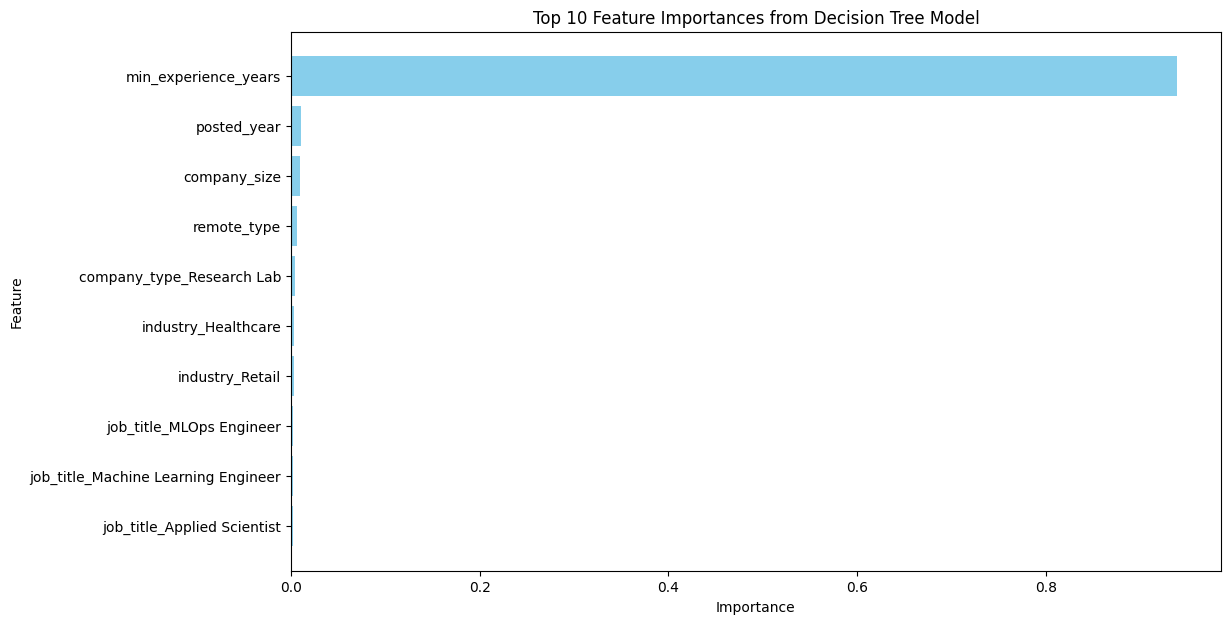

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

#Access the feature_importances_ attribute
feature_importances = dt_classifier.feature_importances_

#Create a Pandas Series to pair importances with feature names
features_df = pd.DataFrame({'feature': X_train.columns, 'importance': feature_importances})

#Sort the feature importances in descending order
features_df = features_df.sort_values(by='importance', ascending=False)

#Display the top N (e.g., top 10) most important features
N = 10
print(f"Top {N} Feature Importances:")
display(features_df.head(N))

#Create a bar plot to visualize the top N feature importances
plt.figure(figsize=(12, 7))
plt.barh(features_df['feature'].head(N), features_df['importance'].head(N), color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title(f'Top {N} Feature Importances from Decision Tree Model')
plt.gca().invert_yaxis() #To display the most important feature at the top
plt.show()

This code extracts feature importances from the trained decision tree model, organizes, and sorts them to identify the most influential features. It then visualizes the top 10 most important features using a horizontal bar plot to provide insights into the model's decision-making.

In [48]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import numpy as np

#Re-load the original data
temp_df = pd.read_csv(url)

#Apply previous cleaning steps
temp_df.drop(columns=['city', 'employment_type'], inplace=True)

#Normalize numerical features
numerical_features = ['salary_min_usd', 'salary_max_usd']
scaler = MinMaxScaler()
temp_df[numerical_features] = scaler.fit_transform(temp_df[numerical_features])

#Calculate 'average_salary' using normalized salary columns
temp_df['average_salary'] = temp_df[['salary_min_usd', 'salary_max_usd']].mean(axis=1)

#Bin 'average_salary' into 'avg_salary_groups'
bins = [0, 0.2, 0.4, 0.6, 0.8, 1]
labels = ['0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8+']
temp_df['avg_salary_groups'] = pd.cut(temp_df['average_salary'], bins=bins, labels=labels, right=False)

#Map 'avg_salary_groups' to numerical labels
salary_group_mapping = {
    '0-0.2': 0,
    '0.2-0.4': 1,
    '0.4-0.6': 2,
    '0.6-0.8': 3,
    '0.8+': 4
}
temp_df['avg_salary_groups_encoded'] = temp_df['avg_salary_groups'].map(salary_group_mapping)

#Convert the 'avg_salary_groups_encoded' column to a numerical type
temp_df['avg_salary_groups_encoded'] = temp_df['avg_salary_groups_encoded'].astype(int)

#Group by 'job_title' and calculate the mean of 'avg_salary_groups_encoded'
avg_salary_by_job_title = temp_df.groupby('job_title')['avg_salary_groups_encoded'].mean()

#Sort in descending order
most_profitable_job_titles = avg_salary_by_job_title.sort_values(ascending=False)

#Display the top 10 most profitable job titles
print("\nTop 10 Most Profitable Job Titles (based on average encoded salary group:\n")
display(most_profitable_job_titles.head(10))


Top 10 Most Profitable Job Titles (based on average encoded salary group:



,avg_salary_groups_encoded
job_title,
Applied Scientist,2.000121
Data Analyst,1.993947
Machine Learning Engineer,1.974444
Data Scientist,1.965517
AI Researcher,1.961735
MLOps Engineer,1.954734


This code block is designed to identify and display the top 10 most profitable job titles based on their average salary groups. It groups the data by 'job_title', computes the mean of these encoded salary groups, and sorts them to show which job titles are associated with higher average salary bands.

# Support Vector Machines (SVM)

In [49]:
import numpy as np
from sklearn.svm import SVC
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Define features (X) and target (y)
X = ai_jobs_df[['remote_type', 'experience_level', 'min_experience_years', 'posted_year', 'company_size']]
y = ai_jobs_df['avg_salary_groups']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Shape of X_train_scaled: {X_train_scaled.shape}")
print(f"Shape of X_test_scaled: {X_test_scaled.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Initialize the SVC model
svm_model = SVC(random_state=42)

# Train the model
svm_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = svm_model.predict(X_test_scaled)

# Evaluate the model
accuracy_svm = accuracy_score(y_test, y_pred)
percision_svm = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall_svm = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1_svm = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# print
print(f"Accuracy: {accuracy_svm:.4f}")
print(f"Percision: {percision_svm:.4f}")
print(f"Recall: {recall_svm:.4f}")
print(f"F1-score: {f1_svm:.4f}")

Shape of X_train_scaled: (40000, 5)
Shape of X_test_scaled: (10000, 5)
Shape of y_train: (40000,)
Shape of y_test: (10000,)
Accuracy: 0.9705
Percision: 0.9436
Recall: 0.9705
F1-score: 0.9564


# Naive Bayes

In [50]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Reusing the X_train, X_test, y_train, y_test prepared in the Decision Trees section
# The Decision Tree cell already handles the full preprocessing and splitting.

# Initialize the Gaussian Naive Bayes classifier
nb_classifier = GaussianNB()

# Train the model
nb_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred_nb = nb_classifier.predict(X_test)



# Evaluate the model
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb, average='weighted', zero_division=0)
recall_nb = recall_score(y_test, y_pred_nb, average='weighted', zero_division=0)
f1_nb = f1_score(y_test, y_pred_nb, average='weighted', zero_division=0)

# Create a DataFrame for evaluation metrics for display
print(f"Accuracy: {accuracy_nb:.4f}")
print(f"Precision: {precision_nb:.4f}")
print(f"Recall: {recall_nb:.4f}")
print(f"F1-score: {f1_nb:.4f}")

Accuracy: 0.9705
Precision: 0.9436
Recall: 0.9705
F1-score: 0.9564


In [51]:
import pandas as pd

# Compare bias-variance tradeoff
# SVM metrics
svm_accuracy = accuracy_svm
svm_precision = percision_svm
svm_recall = recall_svm
svm_f1 = f1_svm

# Decision Tree metrics
dt_accuracy = accuracy_dt
dt_precision = precision_dt
dt_recall = recall_dt
dt_f1 = f1_dt

# Gaussian Naive Bayes metrics
nb_accuracy = accuracy_nb
nb_precision = precision_nb
nb_recall = recall_nb
nb_f1 = f1_nb

comparison_data = {
    'Model': ['Decision Tree', 'Support Vector Machine(SVM)', 'Naive Bayes'],
    'Accuracy': [dt_accuracy, svm_accuracy, nb_accuracy],
    'Precision': [dt_precision, svm_precision, nb_precision],
    'Recall': [dt_recall, svm_recall, nb_recall],
    'F1-score': [dt_f1, svm_f1, nb_f1]
}

comparison_df = pd.DataFrame(comparison_data)

print("\nModel Performance Comparison:")
display(comparison_df.set_index('Model'))


Model Performance Comparison:


,Accuracy,Precision,Recall,F1-score
Model,,,,
Decision Tree,0.9424,0.950734,0.9424,0.946423
Support Vector Machine(SVM),0.9705,0.943560,0.9705,0.956419
Naive Bayes,0.9705,0.943560,0.9705,0.956419


________________________________________________________________________________